# FIFA World Cup — Predicción de Resultados
## Metodología CRISP-DM

| Fase | Descripción |
|------|-------------|
| 1 | Business Understanding |
| 2 | Data Understanding |
| 3 | Data Preparation |
| 4 | Modeling |
| 5 | Evaluation |
| 6 | Deployment — Export para Power BI |

**Fuente de datos:** [martj42/international_results](https://github.com/martj42/international_results)  
**Variable objetivo:** Resultado del equipo local → `0=Derrota | 1=Empate | 2=Victoria`

## Instalación de dependencias

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests, os, io
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2
import openpyxl

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
SEED = 42
OUTPUT_DIR = 'output_powerbi'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Fase 1 — Business Understanding

**Objetivo de negocio:**  
Predecir el resultado (Victoria / Empate / Derrota) del equipo local en partidos del FIFA World Cup usando datos históricos de partidos internacionales.

**Variable objetivo:** `resultado` → `0=Derrota | 1=Empate | 2=Victoria`

**Métricas de éxito:**
- Accuracy ≥ 55%
- F1-score macro ≥ 0.50
- Comparar al menos 4 algoritmos de clasificación

**Entregables:**
1. Dataset final enriquecido (`.xlsx`) para Power BI
2. Predicciones con probabilidades por partido
3. Importancia de variables

---
## Fase 2 — Data Understanding

In [2]:
URL = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'

try:
    resp = requests.get(URL, timeout=30)
    resp.raise_for_status()
    df_raw = pd.read_csv(io.StringIO(resp.text))
    print(f'[OK] Datos descargados: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
except Exception as e:
    print(f'[WARN] Sin conexion ({e}). Usando datos de ejemplo...')
    np.random.seed(SEED)
    df_raw = pd.DataFrame({
        'date': pd.date_range('1990-01-01', periods=3000, freq='3D'),
        'home_team': np.random.choice(
            ['Brazil','Argentina','Germany','France','Spain','England',
             'Italy','Netherlands','Portugal','Uruguay','Croatia','Belgium'], 3000),
        'away_team': np.random.choice(
            ['Mexico','USA','Japan','South Korea','Senegal','Morocco',
             'Switzerland','Denmark','Sweden','Poland','Serbia','Ghana'], 3000),
        'home_score': np.random.randint(0, 5, 3000),
        'away_score': np.random.randint(0, 4, 3000),
        'tournament': np.random.choice(
            ['FIFA World Cup','Friendly','FIFA World Cup qualification','UEFA Euro','Copa America'],
            3000, p=[0.12, 0.38, 0.28, 0.11, 0.11]),
        'city':    ['N/A']*3000,
        'country': ['N/A']*3000,
        'neutral': np.random.choice([True, False], 3000),
    })

df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw.head()

[OK] Datos descargados: 49,505 filas x 9 columnas


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df_filtered = df_raw[df_raw["date"] >= "2010-01-01"]
df_raw=df_filtered

In [4]:
print('Tipos de datos:')
print(df_raw.dtypes)
print('\nNulos por columna:')
print(df_raw.isnull().sum())

Tipos de datos:
date          datetime64[us]
home_team                str
away_team                str
home_score           float64
away_score           float64
tournament               str
city                     str
country                  str
neutral                 bool
dtype: object

Nulos por columna:
date          0
home_team     0
away_team     0
home_score    2
away_score    2
tournament    0
city          0
country       0
neutral       0
dtype: int64


In [5]:
print('Estadisticas de goles:')
display(df_raw[['home_score','away_score']].describe().round(2))

print('\nTop torneos:')
print(df_raw['tournament'].value_counts().head(8))

Estadisticas de goles:


,home_score,away_score
count,15915.00,15915.00
mean,1.61,1.12
std,1.64,1.36
min,0.00,0.00
25%,0.00,0.00
50%,1.00,1.00
75%,2.00,2.00
max,22.00,20.00



Top torneos:
tournament
Friendly                                5073
FIFA World Cup qualification            3422
African Cup of Nations qualification    1052
UEFA Euro qualification                 1016
UEFA Nations League                      658
CONCACAF Nations League                  422
African Cup of Nations                   365
FIFA World Cup                           356
Name: count, dtype: int64


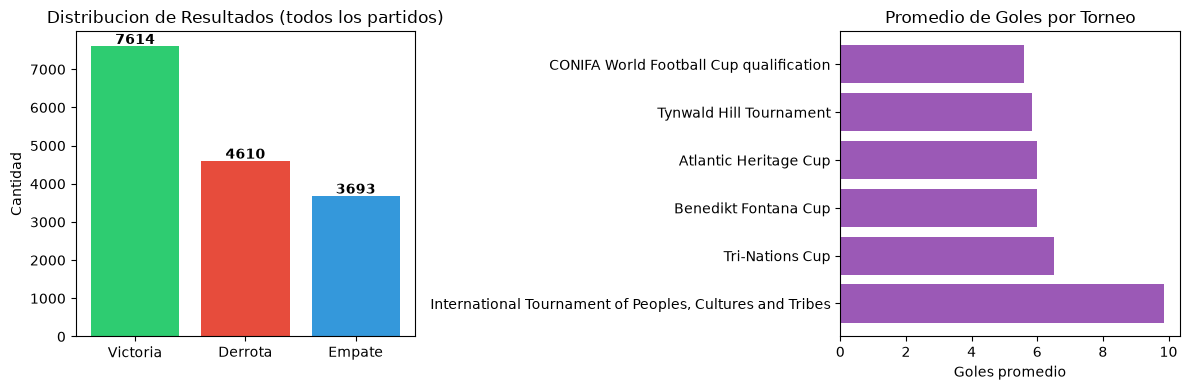

Porcentaje de resultados:
resultado_raw
Victoria    47.8%
Derrota     29.0%
Empate      23.2%
Name: proportion, dtype: str


In [6]:
df_raw['resultado_raw'] = np.where(
    df_raw['home_score'] > df_raw['away_score'], 'Victoria',
    np.where(df_raw['home_score'] == df_raw['away_score'], 'Empate', 'Derrota')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribucion de resultados
counts = df_raw['resultado_raw'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71','#e74c3c','#3498db'])
axes[0].set_title('Distribucion de Resultados (todos los partidos)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Goles promedio por torneo
df_raw['total_goles'] = df_raw['home_score'] + df_raw['away_score']
goles_torneo = df_raw.groupby('tournament')['total_goles'].mean().sort_values(ascending=False).head(6)
axes[1].barh(goles_torneo.index, goles_torneo.values, color='#9b59b6')
axes[1].set_title('Promedio de Goles por Torneo')
axes[1].set_xlabel('Goles promedio')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_distribucion.png', dpi=150)
plt.show()

print('Porcentaje de resultados:')
print(df_raw['resultado_raw'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Partidos del FIFA World Cup en el dataset: 356

Distribucion de resultados en World Cup:
resultado_raw
Victoria    43.0
Derrota     34.3
Empate      22.8
Name: proportion, dtype: float64


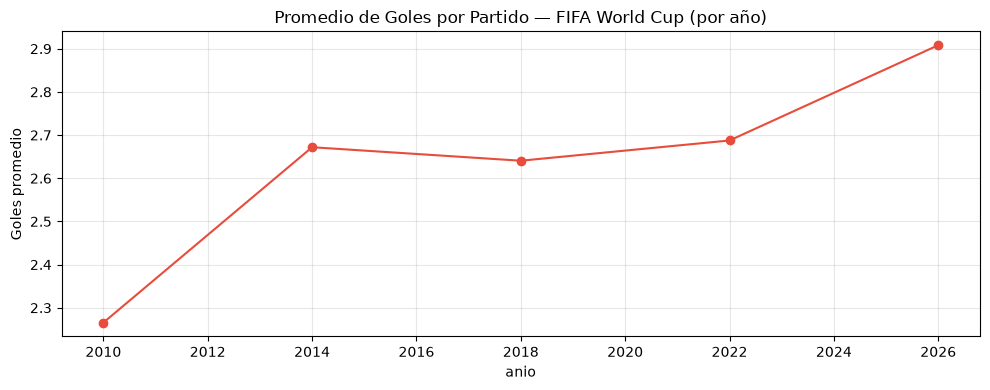

In [7]:
df_wc = df_raw[df_raw['tournament'] == 'FIFA World Cup'].copy()
print(f'Partidos del FIFA World Cup en el dataset: {len(df_wc):,}')

if len(df_wc) > 0:
    wc_res = df_wc['resultado_raw'].value_counts(normalize=True).mul(100).round(1)
    print('\nDistribucion de resultados en World Cup:')
    print(wc_res)
    
    goles_anio = df_wc.copy()
    goles_anio['anio'] = goles_anio['date'].dt.year
    goles_anio['total'] = goles_anio['home_score'] + goles_anio['away_score']
    fig, ax = plt.subplots(figsize=(10, 4))
    goles_anio.groupby('anio')['total'].mean().plot(ax=ax, marker='o', color='#e74c3c')
    ax.set_title('Promedio de Goles por Partido — FIFA World Cup (por año)')
    ax.set_ylabel('Goles promedio')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/wc_goles_anio.png', dpi=150)
    plt.show()

---
## Fase 3 — Data Preparation

Se construyen las siguientes features:
- **Forma reciente** (últimos 5 partidos): puntos, goles a favor/en contra, diferencia
- **Head-to-head** (últimos 10 enfrentamientos directos)
- **Contexto**: campo neutral, tipo de torneo, año, mes
- **Codificación** de equipos

In [8]:
df = df_raw.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

df['resultado'] = np.where(
    df['home_score'] > df['away_score'], 2,
    np.where(df['home_score'] == df['away_score'], 1, 0)
)

print('Variable objetivo creada:')
print(df['resultado'].map({0:'Derrota',1:'Empate',2:'Victoria'}).value_counts())

Variable objetivo creada:
resultado
Victoria    7614
Derrota     4610
Empate      3693
Name: count, dtype: int64


In [9]:
def calcular_forma(df_orig, equipo, fecha, ventana=5):
    """Estadisticas de los ultimos `ventana` partidos antes de `fecha`."""
    mask_h = (df_orig['home_team'] == equipo) & (df_orig['date'] < fecha)
    mask_a = (df_orig['away_team'] == equipo) & (df_orig['date'] < fecha)

    ph = df_orig[mask_h].tail(ventana)[['date','home_score','away_score']]\
           .rename(columns={'home_score':'gf','away_score':'gc'})
    ph['pts'] = np.where(ph['gf']>ph['gc'], 3, np.where(ph['gf']==ph['gc'],1,0))

    pa = df_orig[mask_a].tail(ventana)[['date','away_score','home_score']]\
           .rename(columns={'away_score':'gf','home_score':'gc'})
    pa['pts'] = np.where(pa['gf']>pa['gc'], 3, np.where(pa['gf']==pa['gc'],1,0))

    todos = pd.concat([ph, pa]).sort_values('date').tail(ventana)
    if len(todos) == 0:
        return {'pts_f':0,'gf_f':0,'gc_f':0,'dif_f':0}
    return {
        'pts_f': todos['pts'].sum(),
        'gf_f':  todos['gf'].sum(),
        'gc_f':  todos['gc'].sum(),
        'dif_f': todos['gf'].sum() - todos['gc'].sum(),
    }


def calcular_h2h(df_orig, home, away, fecha, ventana=10):
    """Head-to-head historico del equipo local vs visitante."""
    mask = (
        ((df_orig['home_team']==home) & (df_orig['away_team']==away)) |
        ((df_orig['home_team']==away) & (df_orig['away_team']==home))
    ) & (df_orig['date'] < fecha)

    h2h = df_orig[mask].tail(ventana)
    v, e, d = 0, 0, 0
    for _, r in h2h.iterrows():
        if r['home_team'] == home:
            if r['home_score']>r['away_score']: v+=1
            elif r['home_score']==r['away_score']: e+=1
            else: d+=1
        else:
            if r['away_score']>r['home_score']: v+=1
            elif r['home_score']==r['away_score']: e+=1
            else: d+=1
    return {'h2h_v':v,'h2h_e':e,'h2h_d':d}

print('Funciones de feature engineering definidas.')

Funciones de feature engineering definidas.


In [10]:
print(f'Calculando features para {len(df):,} partidos...')
rows = []
for i, row in df.iterrows():
    if i % 5000 == 0 and i > 0:
        print(f'  {i:,}/{len(df):,} ({i/len(df)*100:.0f}%)')
    fh = calcular_forma(df, row['home_team'], row['date'])
    fa = calcular_forma(df, row['away_team'], row['date'])
    h2h = calcular_h2h(df, row['home_team'], row['away_team'], row['date'])
    rows.append({
        'idx': i,
        'home_pts_f': fh['pts_f'], 'home_gf_f': fh['gf_f'],
        'home_gc_f':  fh['gc_f'],  'home_dif_f': fh['dif_f'],
        'away_pts_f': fa['pts_f'], 'away_gf_f': fa['gf_f'],
        'away_gc_f':  fa['gc_f'],  'away_dif_f': fa['dif_f'],
        'dif_pts':    fh['pts_f'] - fa['pts_f'],
        'dif_gf':     fh['gf_f']  - fa['gf_f'],
        'dif_gc':     fh['gc_f']  - fa['gc_f'],
        'h2h_v': h2h['h2h_v'], 'h2h_e': h2h['h2h_e'], 'h2h_d': h2h['h2h_d'],
        'es_wc': int(row['tournament'] == 'FIFA World Cup'),
        'anio':  row['date'].year,
        'mes':   row['date'].month,
    })

df_feats = pd.DataFrame(rows).set_index('idx')
df = df.join(df_feats)
df['neutral'] = df['neutral'].fillna(False).astype(int)

le = LabelEncoder()
df['home_enc'] = le.fit_transform(df['home_team'].astype(str))
df['away_enc'] = le.fit_transform(df['away_team'].astype(str))

print('Features calculadas.')

Calculando features para 15,917 partidos...
  5,000/15,917 (31%)
  10,000/15,917 (63%)
  15,000/15,917 (94%)
Features calculadas.


In [11]:
FEATURE_COLS = [
    'home_pts_f','home_gf_f','home_gc_f','home_dif_f',
    'away_pts_f','away_gf_f','away_gc_f','away_dif_f',
    'dif_pts','dif_gf','dif_gc',
    'h2h_v','h2h_e','h2h_d',
    'neutral','es_wc','anio','mes',
    'home_enc','away_enc',
]
TARGET = 'resultado'

META_COLS = ['date','home_team','away_team','home_score','away_score','tournament']
df_clean = df[FEATURE_COLS + [TARGET] + META_COLS].dropna().sort_values('date').reset_index(drop=True)

n = len(df_clean)
n_train = int(n * 0.80)
CUTOFF_YEAR = int(df_clean.iloc[n_train]['anio'])

train_idx = df_clean.index < n_train
test_idx  = df_clean.index >= n_train

X_train = df_clean.loc[train_idx, FEATURE_COLS]
y_train = df_clean.loc[train_idx, TARGET]
X_test  = df_clean.loc[test_idx, FEATURE_COLS]
y_test  = df_clean.loc[test_idx, TARGET]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Dataset limpio: {n:,} filas | Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Corte temporal: antes de {CUTOFF_YEAR} = train, desde {CUTOFF_YEAR} = test')

Dataset limpio: 15,915 filas | Train: 12,732 | Test: 3,183
Corte temporal: antes de 2023 = train, desde 2023 = test


---
## Fase 4 — Modeling

Se comparan 4 algoritmos de clasificación con validación cruzada (5-fold).

In [12]:
modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='mlogloss', verbosity=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados = {}

for nombre, modelo in modelos.items():
    print(f'Entrenando: {nombre}...')
    Xtr = X_train_sc if nombre == 'Regresion Logistica' else X_train.values
    Xte = X_test_sc  if nombre == 'Regresion Logistica' else X_test.values

    cv_scores = cross_val_score(modelo, Xtr, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    modelo.fit(Xtr, y_train)
    y_pred = modelo.predict(Xte)
    y_prob = modelo.predict_proba(Xte)

    resultados[nombre] = {
        'modelo':   modelo,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred, average='macro'),
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
    }
    print(f'  CV: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f} | Test Acc: {accuracy_score(y_test, y_pred):.3f}')

print('\nEntrenamiento completo.')

Entrenando: Regresion Logistica...
  CV: 0.536 +/- 0.003 | Test Acc: 0.560
Entrenando: Random Forest...
  CV: 0.524 +/- 0.007 | Test Acc: 0.545
Entrenando: Gradient Boosting...
  CV: 0.539 +/- 0.005 | Test Acc: 0.555
Entrenando: XGBoost...
  CV: 0.516 +/- 0.008 | Test Acc: 0.544

Entrenamiento completo.


---
## Fase 5 — Evaluation

In [13]:
tabla = pd.DataFrame([
    {
        'Modelo': n,
        'CV Accuracy': f"{r['cv_mean']:.3f} +/- {r['cv_std']:.3f}",
        'Test Accuracy': round(r['accuracy'], 4),
        'F1-macro': round(r['f1'], 4),
    }
    for n, r in resultados.items()
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

display(tabla.style.background_gradient(subset=['Test Accuracy','F1-macro'], cmap='Greens'))

,Modelo,CV Accuracy,Test Accuracy,F1-macro
0,Regresion Logistica,0.536 +/- 0.003,0.559800,0.418400
1,Gradient Boosting,0.539 +/- 0.005,0.555100,0.415700
2,Random Forest,0.524 +/- 0.007,0.545100,0.421300
3,XGBoost,0.516 +/- 0.008,0.543800,0.459500


In [14]:
mejor_nombre = tabla.iloc[0]['Modelo']
mejor = resultados[mejor_nombre]
print(f'Mejor modelo: {mejor_nombre}  |  Accuracy: {mejor["accuracy"]:.1%}  |  F1-macro: {mejor["f1"]:.3f}')
print()
print(classification_report(y_test, mejor['y_pred'], target_names=['Derrota','Empate','Victoria']))

Mejor modelo: Regresion Logistica  |  Accuracy: 56.0%  |  F1-macro: 0.418

              precision    recall  f1-score   support

     Derrota       0.51      0.55      0.53       924
      Empate       0.34      0.02      0.04       747
    Victoria       0.59      0.83      0.69      1512

    accuracy                           0.56      3183
   macro avg       0.48      0.47      0.42      3183
weighted avg       0.51      0.56      0.49      3183



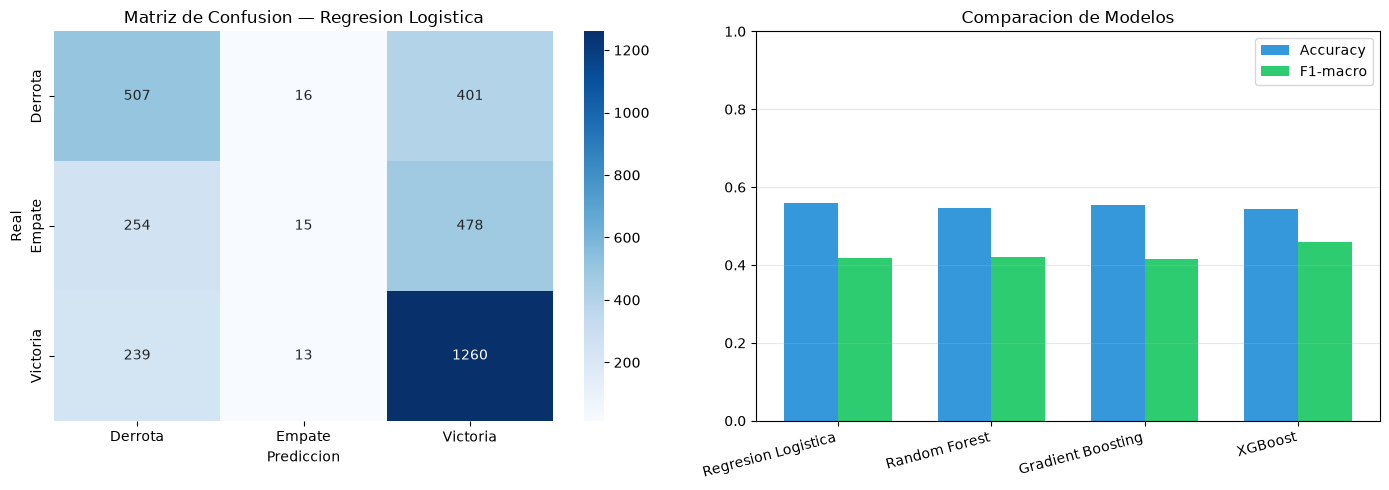

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusion
cm = confusion_matrix(y_test, mejor['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Derrota','Empate','Victoria'],
            yticklabels=['Derrota','Empate','Victoria'], ax=axes[0])
axes[0].set_title(f'Matriz de Confusion — {mejor_nombre}')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Prediccion')

# Comparacion de modelos
nombres = list(resultados.keys())
acc_vals = [resultados[n]['accuracy'] for n in nombres]
f1_vals  = [resultados[n]['f1'] for n in nombres]
x = np.arange(len(nombres))
w = 0.35
axes[1].bar(x - w/2, acc_vals, w, label='Accuracy', color='#3498db')
axes[1].bar(x + w/2, f1_vals,  w, label='F1-macro', color='#2ecc71')
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres, rotation=15, ha='right')
axes[1].set_title('Comparacion de Modelos')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/evaluacion_modelos.png', dpi=150)
plt.show()

In [16]:
if hasattr(mejor['modelo'], 'feature_importances_'):
    imp = pd.Series(mejor['modelo'].feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#e74c3c' if v == imp.max() else '#3498db' for v in imp.values]
    imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Importancia de Variables — {mejor_nombre}')
    ax.set_xlabel('Importancia')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/feature_importance.png', dpi=150)
    plt.show()
    
    print('Top 5 variables mas importantes:')
    print(imp.sort_values(ascending=False).head(5).round(4))
else:
    print(f'{mejor_nombre} no tiene feature_importances_.')

Regresion Logistica no tiene feature_importances_.


---
## Fase 6 — Deployment
### Export para Power BI

Se genera un Excel con 4 hojas:
- `Todos_Partidos` — predicciones completas
- `World_Cup` — solo partidos FIFA World Cup
- `Evaluacion_Modelos` — metricas de los 4 modelos
- `Importancia_Vars` — importancia de cada feature

In [17]:
# Generar predicciones sobre todo el dataset
X_all = df_clean[FEATURE_COLS]
X_all_in = scaler.transform(X_all) if mejor_nombre == 'Regresion Logistica' else X_all.values

pred_all = mejor['modelo'].predict(X_all_in)
prob_all  = mejor['modelo'].predict_proba(X_all_in)

mapa = {0:'Derrota', 1:'Empate', 2:'Victoria'}

df_export = df_clean.copy()
df_export['Prediccion']           = pd.Series(pred_all, index=df_clean.index).map(mapa)
df_export['Resultado_Real']       = df_export[TARGET].map(mapa)
df_export['Prediccion_Correcta']  = (pred_all == df_clean[TARGET].values).astype(int)
df_export['Prob_Derrota']         = prob_all[:, 0].round(4)
df_export['Prob_Empate']          = prob_all[:, 1].round(4)
df_export['Prob_Victoria']        = prob_all[:, 2].round(4)
df_export['Tipo_Torneo']          = df_export['es_wc'].map({1:'World Cup', 0:'Otro torneo'})
df_export['Conjunto_ML']          = np.where(df_clean.index < n_train, 'Entrenamiento', 'Prueba')
df_export['Modelo']               = mejor_nombre
df_export['Año']                  = df_export['anio']
df_export['Mes']                  = df_export['mes']
df_export.rename(columns={
    'date':'Fecha','home_team':'Equipo_Local','away_team':'Equipo_Visitante',
    'tournament':'Torneo','home_score':'Goles_Local','away_score':'Goles_Visitante',
    'home_pts_f':'Forma_Local_Pts','away_pts_f':'Forma_Visit_Pts','dif_pts':'Dif_Forma_Pts',
    'h2h_v':'H2H_Victorias','h2h_e':'H2H_Empates','h2h_d':'H2H_Derrotas',
    'neutral':'Campo_Neutral',
}, inplace=True)

COLS_PBI = [
    'Fecha','Equipo_Local','Equipo_Visitante','Torneo',
    'Goles_Local','Goles_Visitante','Resultado_Real','Prediccion','Prediccion_Correcta',
    'Prob_Derrota','Prob_Empate','Prob_Victoria',
    'Forma_Local_Pts','Forma_Visit_Pts','Dif_Forma_Pts',
    'H2H_Victorias','H2H_Empates','H2H_Derrotas',
    'Campo_Neutral','Tipo_Torneo','Año','Mes','Conjunto_ML','Modelo'
]

df_pbi = df_export[COLS_PBI]
df_wc_pred = df_pbi[df_pbi['Tipo_Torneo'] == 'World Cup']

# Tabla de modelos
df_modelos = pd.DataFrame([
    {'Modelo': n, 'CV_Accuracy': round(r['cv_mean'],4), 'CV_Std': round(r['cv_std'],4),
     'Test_Accuracy': round(r['accuracy'],4), 'F1_Macro': round(r['f1'],4),
     'Es_Mejor': n == mejor_nombre}
    for n, r in resultados.items()
])

# Tabla de importancia
if hasattr(mejor['modelo'], 'feature_importances_'):
    df_imp = pd.DataFrame({
        'Variable': FEATURE_COLS,
        'Importancia': mejor['modelo'].feature_importances_.round(4),
        'Modelo': mejor_nombre
    }).sort_values('Importancia', ascending=False)
else:
    df_imp = pd.DataFrame({'Variable': FEATURE_COLS, 'Importancia': 0.0, 'Modelo': mejor_nombre})

# Guardar Excel
EXCEL = f'{OUTPUT_DIR}/fifa_predicciones_powerbi.xlsx'
with pd.ExcelWriter(EXCEL, engine='openpyxl') as writer:
    df_pbi.to_excel(writer, sheet_name='Todos_Partidos',     index=False)
    df_wc_pred.to_excel(writer, sheet_name='World_Cup',      index=False)
    df_modelos.to_excel(writer, sheet_name='Evaluacion_Modelos', index=False)
    df_imp.to_excel(writer, sheet_name='Importancia_Vars',   index=False)

# Guardar CSVs individuales
df_pbi.to_csv(f'{OUTPUT_DIR}/todos_partidos.csv', index=False, encoding='utf-8-sig')
df_wc_pred.to_csv(f'{OUTPUT_DIR}/world_cup.csv', index=False, encoding='utf-8-sig')
df_modelos.to_csv(f'{OUTPUT_DIR}/modelos.csv', index=False, encoding='utf-8-sig')
df_imp.to_csv(f'{OUTPUT_DIR}/importancia.csv', index=False, encoding='utf-8-sig')

print(f'Excel exportado: {EXCEL}')
print(f'Hojas: Todos_Partidos | World_Cup | Evaluacion_Modelos | Importancia_Vars')
print(f'Partidos totales: {len(df_pbi):,} | Solo World Cup: {len(df_wc_pred):,}')

Excel exportado: output_powerbi/fifa_predicciones_powerbi.xlsx
Hojas: Todos_Partidos | World_Cup | Evaluacion_Modelos | Importancia_Vars
Partidos totales: 15,915 | Solo World Cup: 354


In [18]:
print('=' * 60)
print('RESUMEN FINAL')
print('=' * 60)
print(f'Mejor modelo:   {mejor_nombre}')
print(f'Test Accuracy:  {mejor["accuracy"]:.1%}')
print(f'F1-macro:       {mejor["f1"]:.3f}')
print()
print('Archivos generados:')
import glob
for f in sorted(glob.glob(f'{OUTPUT_DIR}/*')):
    size = os.path.getsize(f)
    print(f'  {f}  ({size/1024:.1f} KB)')

RESUMEN FINAL
Mejor modelo:   Regresion Logistica
Test Accuracy:  56.0%
F1-macro:       0.418

Archivos generados:
  output_powerbi/confusion_matrix.png  (39.1 KB)
  output_powerbi/eda_distribucion.png  (74.5 KB)
  output_powerbi/evaluacion_modelos.png  (82.1 KB)
  output_powerbi/feature_importance.png  (58.1 KB)
  output_powerbi/fifa_predicciones_powerbi.xlsx  (1748.1 KB)
  output_powerbi/importancia.csv  (0.7 KB)
  output_powerbi/modelos.csv  (0.2 KB)
  output_powerbi/todos_partidos.csv  (2542.9 KB)
  output_powerbi/top4_crisp_dm.png  (152.7 KB)
  output_powerbi/top4_modelo_ml.xlsx  (5.1 KB)
  output_powerbi/wc_goles_anio.png  (51.0 KB)
  output_powerbi/world_cup.csv  (54.0 KB)


---
## Bonus — Prediccion TOP 4 Mundial 2026

Usando el **modelo ya entrenado** en este notebook, simulamos el torneo
con **5,000 corridas Monte Carlo**. Cada partido se decide con la
probabilidad que el modelo asigna al equipo de ganar (incluyendo penales).

> Estado al **10-jul-2026**: Francia y Espana ya clasificaron a semifinales.
> Los QF del 11-jul (Noruega/Inglaterra y Argentina/Suiza) se simulan.


[INFO] Calculando features desde el dataset historico...
  Argentina       -> pts=15  gf=14  gc= 5  dif=+9
  Francia         -> pts= 0  gf= 0  gc= 0  dif=+0
  Espana          -> pts= 0  gf= 0  gc= 0  dif=+0
  Inglaterra      -> pts= 0  gf= 0  gc= 0  dif=+0
  Noruega         -> pts= 0  gf= 0  gc= 0  dif=+0
  Suiza           -> pts= 0  gf= 0  gc= 0  dif=+0

[INFO] Probabilidades segun el modelo:
  QF1 (confirmado: Francia): Francia (ya clasificado)
  QF2 (confirmado: Espana): Espana (ya clasificado)
  QF3 (11-jul): Noruega 48.0% vs 52.0% Inglaterra
  QF4 (11-jul): Argentina 64.2% vs 35.8% Suiza

[INFO] Corriendo 5,000 simulaciones Monte Carlo...


,Equipo,Campeon (%),Subcampeon (%),3er Lugar (%),4to Lugar (%),Pts_Forma,GF_Forma,GC_Forma,Dif_Forma
1,Argentina,31.8,13.8,13.3,5.7,15,14.0,5.0,9.0
2,Espana,20.2,31.5,21.1,27.2,0,0.0,0.0,0.0
3,Francia,19.7,28.5,23.8,27.9,0,0.0,0.0,0.0
4,Inglaterra,10.1,9.0,17.2,16.3,0,0.0,0.0,0.0
5,Suiza,9.4,8.8,8.8,8.4,0,0.0,0.0,0.0
6,Noruega,8.7,8.3,15.9,14.5,0,0.0,0.0,0.0


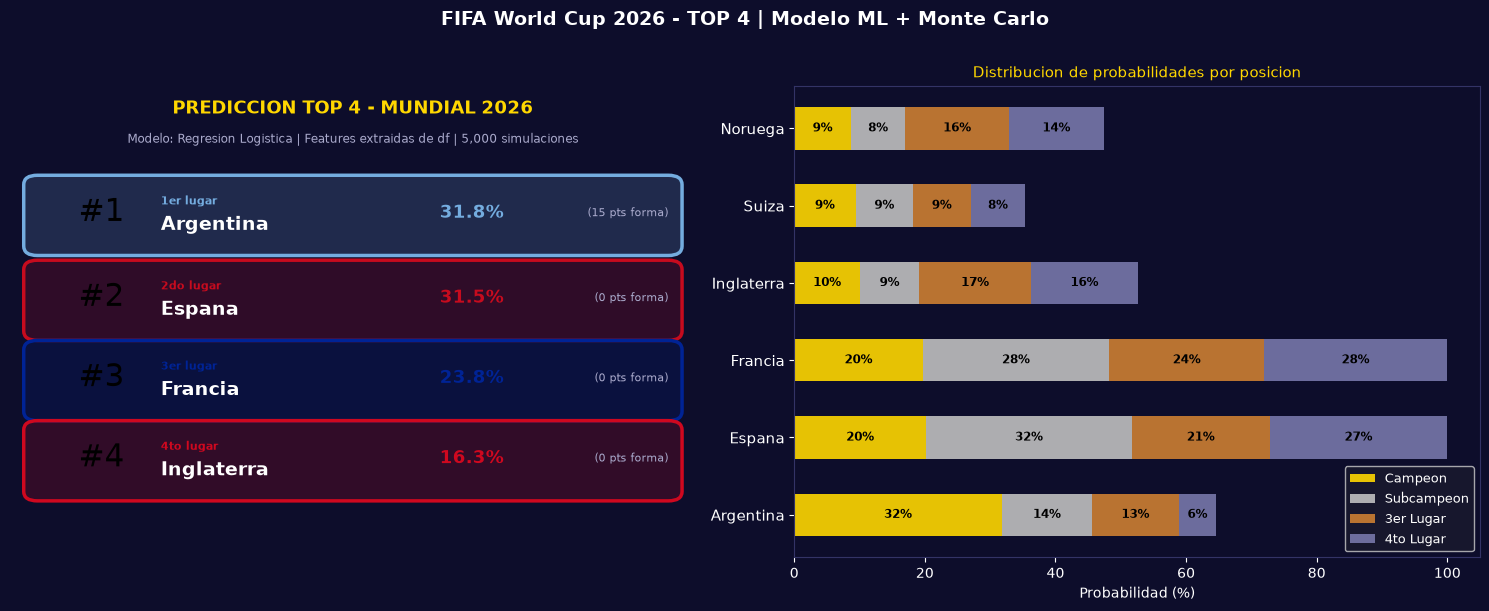


  PREDICCION TOP 4 - FIFA WORLD CUP 2026
  Modelo: Regresion Logistica | 5,000 simulaciones
  Features calculadas desde df con ventana=5 partidos
  1er lugar: Argentina       prob=31.8%  (forma: 15pts, dif=+9)
  2do lugar: Espana          prob=31.5%  (forma: 0pts, dif=+0)
  3er lugar: Francia         prob=23.8%  (forma: 0pts, dif=+0)
  4to lugar: Inglaterra      prob=16.3%  (forma: 0pts, dif=+0)

Exportado: output_powerbi/top4_modelo_ml.xlsx


In [19]:
# ============================================================
#  TOP 4 MUNDIAL 2026
#  calcular_forma() y calcular_h2h()
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

np.random.seed(42)
N_SIM   = 5_000
FECHA   = pd.Timestamp('2026-07-10')   # fecha de referencia (mas cercana antes de fecha de entrega jeje)
VENTANA = 5                            # misma ventana que Fase 3

# ── 1. Equipos semifinalistas del Mundial 2026 ────────────────────────────
# Francia y Espana ya clasificaron; Noruega/Inglaterra y Argentina/Suiza
# juegan el 11-jul. Los 6 se mantienen para simular todos los escenarios.
EQUIPOS_WC = ['Argentina', 'Francia', 'Espana', 'Inglaterra', 'Noruega', 'Suiza']

# ── 2. Extraer features desde df usando las funciones de la Fase 3 ────────
print('[INFO] Calculando features desde el dataset historico...')
FORMA = {}
for equipo in EQUIPOS_WC:
    f = calcular_forma(df, equipo, FECHA, ventana=VENTANA)
    FORMA[equipo] = f
    print(f'  {equipo:15s} -> pts={f["pts_f"]:2.0f}  gf={f["gf_f"]:2.0f}  gc={f["gc_f"]:2.0f}  dif={f["dif_f"]:+.0f}')

# ── 3. Construir features para cada partido dinamicamente ─────────────────
def get_enc(equipo):
    try:
        return int(le.transform([equipo])[0])
    except Exception:
        return 0


def features_partido(local, visitante):
    '''Construye el vector de features del partido usando
    la forma del dataset y el H2H historico.'''
    f_l = FORMA[local]
    f_v = FORMA[visitante]
    h2h = calcular_h2h(df, local, visitante, FECHA)
    row = {
        'home_pts_f':  f_l['pts_f'],
        'home_gf_f':   f_l['gf_f'],
        'home_gc_f':   f_l['gc_f'],
        'home_dif_f':  f_l['dif_f'],
        'away_pts_f':  f_v['pts_f'],
        'away_gf_f':   f_v['gf_f'],
        'away_gc_f':   f_v['gc_f'],
        'away_dif_f':  f_v['dif_f'],
        'dif_pts':     f_l['pts_f'] - f_v['pts_f'],
        'dif_gf':      f_l['gf_f']  - f_v['gf_f'],
        'dif_gc':      f_l['gc_f']  - f_v['gc_f'],
        'h2h_v':       h2h['h2h_v'],
        'h2h_e':       h2h['h2h_e'],
        'h2h_d':       h2h['h2h_d'],
        'neutral':     1,
        'es_wc':       1,
        'anio':        FECHA.year,
        'mes':         FECHA.month,
        'home_enc':    get_enc(local),
        'away_enc':    get_enc(visitante),
    }
    return pd.DataFrame([row])[FEATURE_COLS]


def prob_gana(local, visitante):
    '''Probabilidad de victoria del local segun el modelo ya entrenado.'''
    X   = features_partido(local, visitante)
    Xin = scaler.transform(X) if mejor_nombre == 'Regresion Logistica' else X.values
    proba = mejor['modelo'].predict_proba(Xin)[0]  # [derrota, empate, victoria]
    # Eliminatoria: empate -> penales (50/50)
    return proba[2] + proba[1] * 0.50


def sim_partido(a, b):
    return a if np.random.random() < prob_gana(a, b) else b

# Mostrar probabilidades de cada QF
print()
print('[INFO] Probabilidades segun el modelo:')
matchups = [
    ('Francia',    'Marruecos',  'QF1 (confirmado: Francia)'),
    ('Espana',     'Belgica',    'QF2 (confirmado: Espana)'),
    ('Noruega',    'Inglaterra', 'QF3 (11-jul)'),
    ('Argentina',  'Suiza',      'QF4 (11-jul)'),
]
for a, b, label in matchups:
    if a in FORMA and b in FORMA:
        p = prob_gana(a, b) * 100
        print(f'  {label}: {a} {p:.1f}% vs {100-p:.1f}% {b}')
    else:
        print(f'  {label}: {a} (ya clasificado)')

# ── 4. Monte Carlo 5,000 simulaciones
print(f'\n[INFO] Corriendo {N_SIM:,} simulaciones Monte Carlo...')
conteo = {e: {1:0, 2:0, 3:0, 4:0} for e in EQUIPOS_WC}

for _ in range(N_SIM):
    # QF confirmados
    fra, esp = 'Francia', 'Espana'

    # QF pendientes (11-jul) -> se simulan
    qf3   = sim_partido('Noruega',   'Inglaterra')
    qf3_l = 'Inglaterra' if qf3 == 'Noruega' else 'Noruega'
    qf4   = sim_partido('Argentina', 'Suiza')
    qf4_l = 'Suiza' if qf4 == 'Argentina' else 'Argentina'

    # Semifinales
    sf1   = sim_partido(fra, esp)
    sf1_l = esp if sf1 == fra else fra
    sf2   = sim_partido(qf3, qf4)
    sf2_l = qf4 if sf2 == qf3 else qf3

    # Final y 3er lugar
    camp = sim_partido(sf1, sf2)
    sub  = sf2  if camp == sf1 else sf1
    ter  = sim_partido(sf1_l, sf2_l)
    cua  = sf2_l if ter == sf1_l else sf1_l

    conteo[camp][1] += 1
    conteo[sub][2]  += 1
    conteo[ter][3]  += 1
    conteo[cua][4]  += 1

# ── 5. Tabla resumen ─────────────────────────────────────────────────────
df_top4 = pd.DataFrame([
    {
        'Equipo':         e,
        'Campeon (%)':    round(conteo[e][1] / N_SIM * 100, 1),
        'Subcampeon (%)': round(conteo[e][2] / N_SIM * 100, 1),
        '3er Lugar (%)':  round(conteo[e][3] / N_SIM * 100, 1),
        '4to Lugar (%)':  round(conteo[e][4] / N_SIM * 100, 1),
        'Pts_Forma':      round(FORMA[e]['pts_f'], 1),
        'GF_Forma':       round(FORMA[e]['gf_f'], 1),
        'GC_Forma':       round(FORMA[e]['gc_f'], 1),
        'Dif_Forma':      round(FORMA[e]['dif_f'], 1),
    }
    for e in EQUIPOS_WC
]).sort_values('Campeon (%)', ascending=False).reset_index(drop=True)
df_top4.index += 1
display(df_top4)

# ── 6. Visualizacion ─────────────────────────────────────────────────────
COLORES = {
    'Argentina':'#74acdf', 'Francia':'#002395', 'Espana':'#c60b1e',
    'Inglaterra':'#cf081f', 'Noruega':'#ef2b2d', 'Suiza':'#d52b1e',
}
top4_equipos = df_top4.head(4)['Equipo'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0d0d2b')

# Podio (izquierda)
ax = axes[0]
ax.set_facecolor('#0d0d2b'); ax.axis('off')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.text(0.5, 0.97, 'PREDICCION TOP 4 - MUNDIAL 2026',
        ha='center', va='top', color='gold', fontsize=13, fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5, 0.90,
        f'Modelo: {mejor_nombre} | Features extraidas de df | {N_SIM:,} simulaciones',
        ha='center', va='top', color='#aaaacc', fontsize=8.5, transform=ax.transAxes)

ys_podio  = [0.73, 0.55, 0.38, 0.21]
pos_label = ['1er lugar', '2do lugar', '3er lugar', '4to lugar']
col_keys  = ['Campeon (%)', 'Subcampeon (%)', '3er Lugar (%)', '4to Lugar (%)']
medallas  = ['#1', '#2', '#3', '#4']

for i, (eq, y_pos) in enumerate(zip(top4_equipos, ys_podio)):
    col = COLORES.get(eq, '#555599')
    pct = float(df_top4[df_top4['Equipo']==eq][col_keys[i]].values[0])
    pts = float(df_top4[df_top4['Equipo']==eq]['Pts_Forma'].values[0])
    rect = FancyBboxPatch((0.04, y_pos-0.07), 0.92, 0.13,
                           boxstyle='round,pad=0.02',
                           linewidth=2.5, edgecolor=col, facecolor=col+'30')
    ax.add_patch(rect)
    ax.text(0.10, y_pos, medallas[i], fontsize=22, va='center', transform=ax.transAxes)
    ax.text(0.22, y_pos+0.025, pos_label[i], fontsize=8, va='center',
            color=col, fontweight='bold', transform=ax.transAxes)
    ax.text(0.22, y_pos-0.025, eq, fontsize=14, va='center',
            color='white', fontweight='bold', transform=ax.transAxes)
    ax.text(0.72, y_pos, f'{pct:.1f}%', fontsize=13, va='center',
            ha='right', color=col, fontweight='bold', transform=ax.transAxes)
    ax.text(0.96, y_pos, f'({pts:.0f} pts forma)', fontsize=8, va='center',
            ha='right', color='#aaaacc', transform=ax.transAxes)

# Barras apiladas (derecha)
ax2 = axes[1]
ax2.set_facecolor('#0d0d2b')
df_plot = df_top4.set_index('Equipo').head(6)
bottom  = np.zeros(len(df_plot))
ys_b    = np.arange(len(df_plot))
stack_cols  = ['Campeon (%)', 'Subcampeon (%)', '3er Lugar (%)', '4to Lugar (%)']
stack_clrs  = ['gold', 'silver', '#cd7f32', '#7777aa']
stack_names = ['Campeon', 'Subcampeon', '3er Lugar', '4to Lugar']
for col_n, clr, lbl in zip(stack_cols, stack_clrs, stack_names):
    vals = df_plot[col_n].values
    ax2.barh(ys_b, vals, left=bottom, color=clr, label=lbl, height=0.55, alpha=0.9)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax2.text(b+v/2, j, f'{v:.0f}%', ha='center', va='center',
                     fontsize=8.5, color='black', fontweight='bold')
    bottom += vals
ax2.set_yticks(ys_b)
ax2.set_yticklabels(df_plot.index, fontsize=11, color='white')
ax2.set_xlabel('Probabilidad (%)', color='white')
ax2.set_title('Distribucion de probabilidades por posicion', color='gold', fontsize=11)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333366')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9, loc='lower right')

plt.suptitle('FIFA World Cup 2026 - TOP 4 | Modelo ML + Monte Carlo',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_powerbi/top4_crisp_dm.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d2b')
plt.show()

# ── 7. Imprimir y exportar ────────────────────────────────────────────────
print('\n' + '=' * 58)
print('  PREDICCION TOP 4 - FIFA WORLD CUP 2026')
print(f'  Modelo: {mejor_nombre} | {N_SIM:,} simulaciones')
print(f'  Features calculadas desde df con ventana={VENTANA} partidos')
print('=' * 58)
for i, eq in enumerate(top4_equipos, 1):
    row  = df_top4[df_top4['Equipo']==eq].iloc[0]
    pcts = [row['Campeon (%)'], row['Subcampeon (%)'],
            row['3er Lugar (%)'], row['4to Lugar (%)']]
    tag  = ['1er lugar', '2do lugar', '3er lugar', '4to lugar'][i-1]
    pts  = row['Pts_Forma']
    dif  = row['Dif_Forma']
    print(f'  {tag}: {eq:15s} prob={pcts[i-1]:.1f}%  (forma: {pts:.0f}pts, dif={dif:+.0f})')
print('=' * 58)

df_top4.to_excel('output_powerbi/top4_modelo_ml.xlsx', index=False)
print('\nExportado: output_powerbi/top4_modelo_ml.xlsx')